<a href="https://colab.research.google.com/github/QustaB/Time-Series-and-Tableau-Belt-exam-DS-11.25/blob/main/Belt_Exam_part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Version A: Data Viz
## Part 2

In [ ]:
!pip install pmdarima
import pmdarima as pm


import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
import statsmodels.api as sm
import pmdarima as pm
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.5 MB/s eta 0:00:00


In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")

    # Plotting test data if provided
    if ts_test is not None:
        ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [ ]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [ ]:
PATH = '/content/drive/MyDrive/AXSOSACADEMY/Belt exam/zillow_home_values-zipcode.csv'
df = pd.read_csv(PATH,low_memory=False)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [ ]:
# Identify identifier columns and date columns
identifier_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
# 2. Melt the data to long-form
df_melted = df.melt(id_vars=identifier_cols, var_name='Date', value_name='Home Value')
df_melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0


In [ ]:
# 3. Convert the melted dates into datetime datatype
df_melted['Date'] = pd.to_datetime(df_melted['Date'],format='%d%m%Y')
df_melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   RegionID    int64         
 1   SizeRank    int64         
 2   RegionName  int64         
 3   RegionType  object        
 4   StateName   object        
 5   State       object        
 6   City        object        
 7   Metro       object        
 8   CountyName  object        
 9   Date        datetime64[ns]
 10  Home Value  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 633.3+ MB


In [ ]:
# 4. Make the datetime column the index (and prepare for resampling by city)
df_melted = df_melted.set_index('Date')
df_melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


In [ ]:
#  FiltercOR  cities
df_filtered = df_melted[df_melted['State'].isin(['OR'])].copy()
df_filtered.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,99142,262,97229,zip,OR,OR,Portland,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,260209.0
2000-01-31,99178,489,97301,zip,OR,OR,Salem,"Salem, OR",Marion County,109851.0
2000-01-31,99048,528,97045,zip,OR,OR,Oregon City,"Portland-Vancouver-Hillsboro, OR-WA",Clackamas County,204570.0
2000-01-31,99093,549,97124,zip,OR,OR,Hillsboro,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,181574.0
2000-01-31,99252,656,97402,zip,OR,OR,Eugene,"Eugene-Springfield, OR",Lane County,136799.0


In [ ]:
df_filtered= df_filtered.loc['2000':'2018']
df_filtered.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,99142,262,97229,zip,OR,OR,Portland,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,260209.0
2000-01-31,99178,489,97301,zip,OR,OR,Salem,"Salem, OR",Marion County,109851.0
2000-01-31,99048,528,97045,zip,OR,OR,Oregon City,"Portland-Vancouver-Hillsboro, OR-WA",Clackamas County,204570.0
2000-01-31,99093,549,97124,zip,OR,OR,Hillsboro,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,181574.0
2000-01-31,99252,656,97402,zip,OR,OR,Eugene,"Eugene-Springfield, OR",Lane County,136799.0


In [ ]:
# 5. Resample the dataframe as monthly frequency, grouped by City (RegionName)
df_resampled = df_filtered.groupby('Date')['Home Value'].mean()
df_resampled.info()
df_resampled.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 228 entries, 2000-01-31 to 2018-12-31
Series name: Home Value
Non-Null Count  Dtype  
--------------  -----  
228 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB


,Home Value
Date,
2000-01-31,162508.613445
2000-02-29,162913.172269
2000-03-31,163011.125523
2000-04-30,163541.908333
2000-05-31,164176.420833


In [ ]:
df_resampled.tail()

,Home Value
Date,
2018-08-31,313844.697059
2018-09-30,315055.305882
2018-10-31,316216.785294
2018-11-30,317505.623529
2018-12-31,319024.661765


In [ ]:
df_resampled.isnull().sum()

np.int64(0)

<Axes: xlabel='Date'>

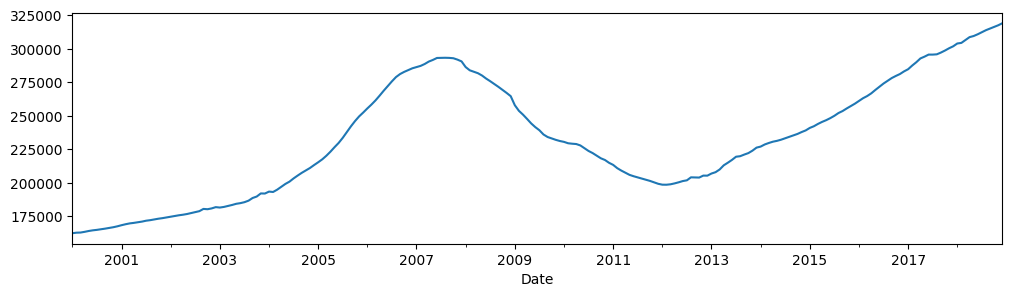

In [ ]:
# Set wide fig size for plots
plt.rcParams['figure.figsize']=(12,3)
df_resampled.plot()

In [ ]:
ts=df_resampled

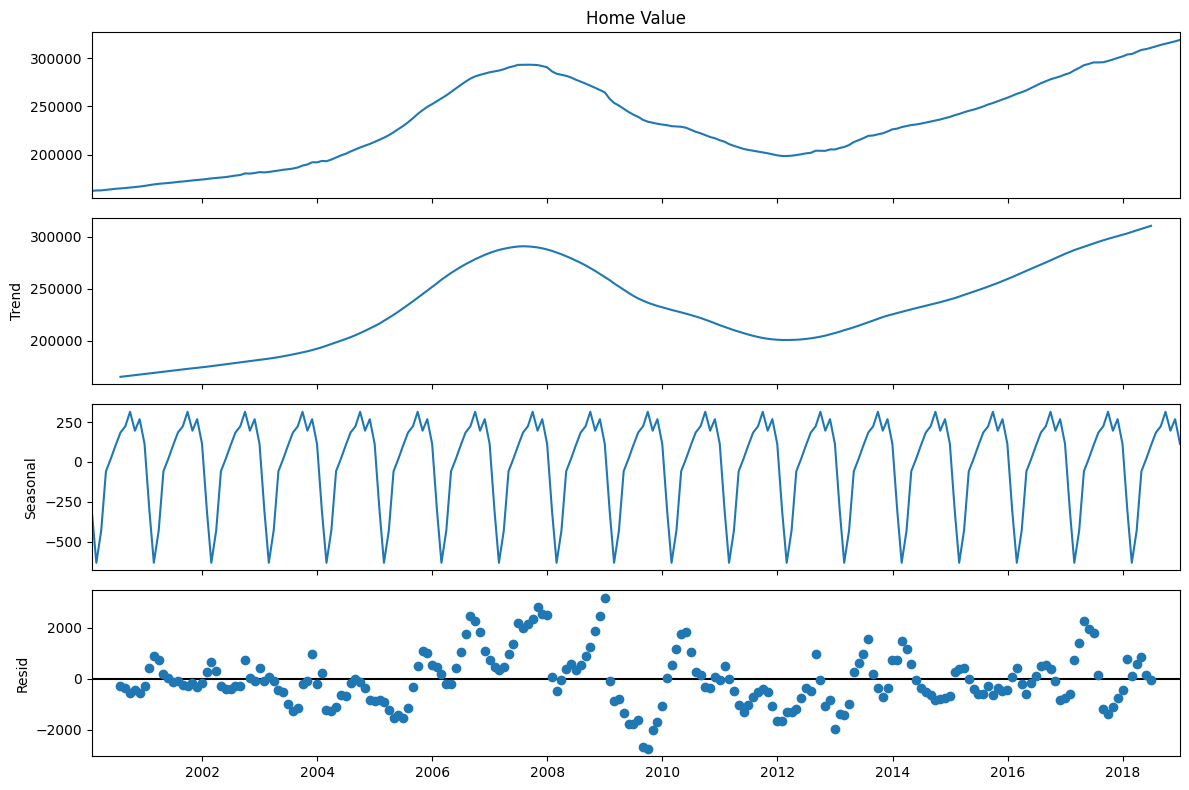

In [ ]:
# Apply seasonal decomposition
decomp = tsa.seasonal_decompose(ts)
fig = decomp.plot()
fig.set_size_inches(12,8)
fig.tight_layout()

In [ ]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta: .2f} which is ~{seasonal_delta/(ts.max()-ts.min()) * 100 :.2f}% of the variation in time series.")

The seasonal component is  948.43 which is ~0.61% of the variation in time series.


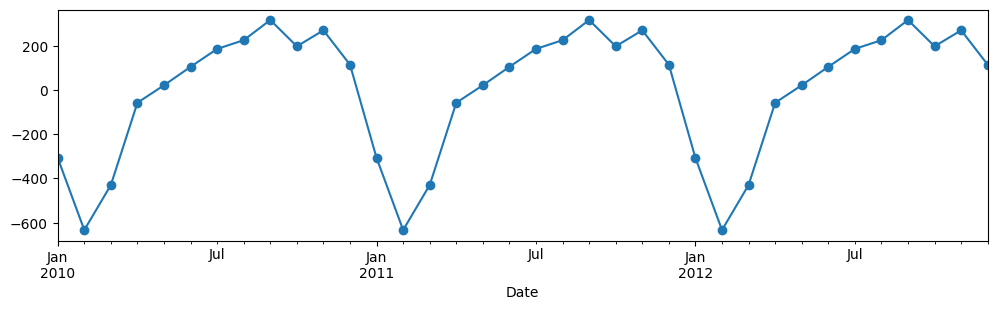

In [ ]:
# Narrow down the date range of the plot
seasonal = decomp.seasonal
ax = seasonal.loc['2010': '2012'].plot(marker = 'o')

Check for stationarity and determine differencing

In [ ]:
# Check for stationarity
get_adfuller_results(ts)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


In [ ]:
# determine d
d = ndiffs(ts)
print (f'd = {d}')
# determine D
D = nsdiffs(ts, m = 12)
print (f'D = {D}')

d = 2
D = 0


- D=2 differencing is required two times for nonseasonal
- D=0  differencing is not required for seasonal

          Test Statistic  # of Lags Used  # of Observations  p-value  alpha  \
adfuller      -13.956007               1                224      0.0   0.05   

          sig/stationary?  
adfuller             True  


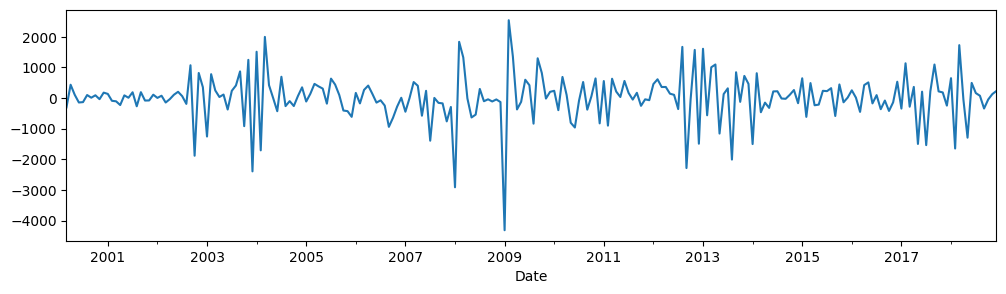

In [ ]:
# apply both differencings
ts_diff = ts.diff().diff().dropna()
# Check for stationarity
print(get_adfuller_results(ts_diff))
ts_diff.plot();

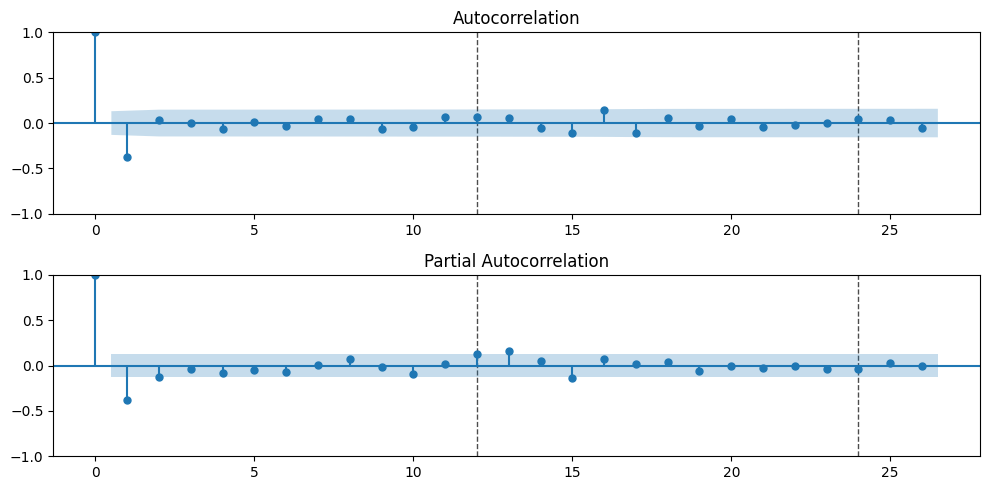

In [ ]:
# now look at the acf/pacf of the stationary data
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags = 26);

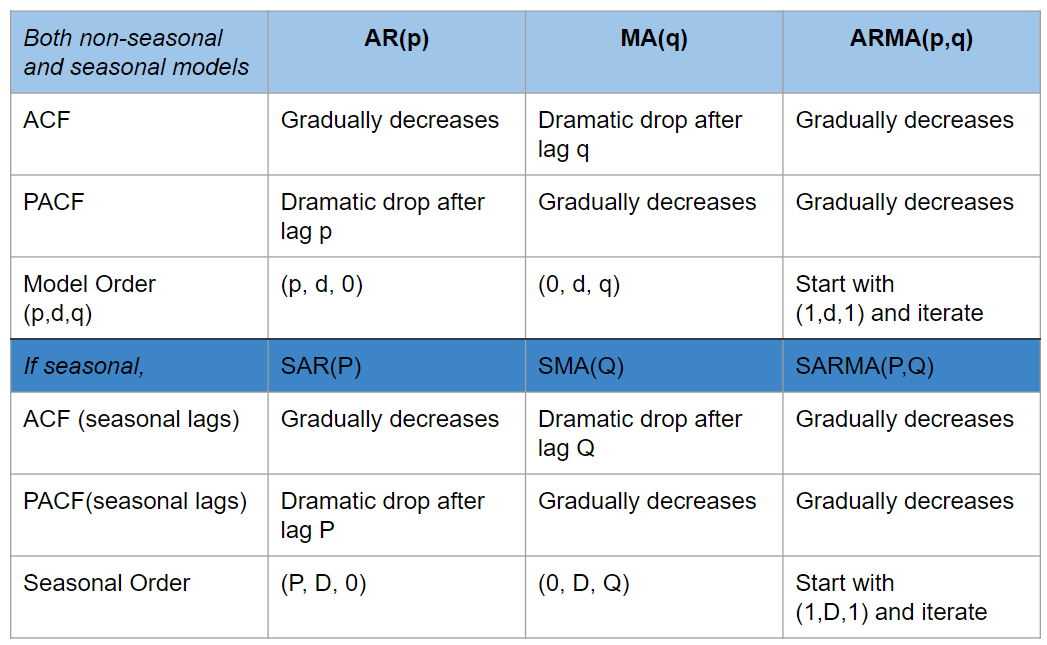

In this case, the plots reveal obvious values for the orders. We see a **gradually decreases** in both the ACF and PACF. In this case, we could use a 1 for both the AR and MA. We see the seasonal lags in ACF plot Dramaticly drop,and Gradually decreases in PACF plot so we will try P = 0 and Q = 1. Remember, this is just an educated starting point. We will try other orders before deciding on the final model.

Therefore, a potential SARIMA model order could be SARIMA(1, 2, 1)(0, 0, 1)[12].

Train Test Split

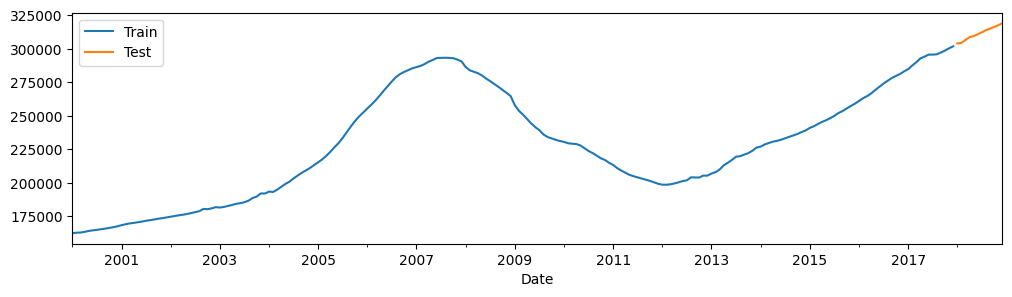

In [ ]:
# tts
train, test = train_test_split(ts, test_size=12)
# train = ts.iloc[:-12]   # all but last 12 months
# test  = ts.iloc[-12:]   # last 12 months
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend();

Fit initial model

In [ ]:
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1  # nonseasonal MA

# Orders for seasonal components
P = 0  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

arima_model = tsa.ARIMA(train, order=(p,d,q)).fit()
sarima = tsa.SARIMAX(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_date

In [ ]:
# Obtain summary
arima_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1725.837
Date:                Tue, 21 Apr 2026   AIC                           3457.674
Time:                        22:45:07   BIC                           3467.772
Sample:                    01-31-2000   HQIC                          3461.755
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5758      1.083      0.532      0.595      -1.548       2.699
ma.L1         -0.5967      1.091     -0.547      0.585      -2.735       1.542
sigma2      5.151e+05    2.2e+04     23.396      0.000    4.72e+05    5.58e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.30   Jarque-Bera (JB):               363.31
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.16
Prob(H) (two-sided):                  0.28   Kurtosis:                         8.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Home Value   No. Observations:                  216
Model:             SARIMAX(1, 2, 1)x(0, 0, 1, 12)   Log Likelihood               -1725.730
Date:                            Tue, 21 Apr 2026   AIC                           3459.460
Time:                                    22:45:20   BIC                           3472.924
Sample:                                01-31-2000   HQIC                          3464.900
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5738      1.093      0.525      0.600      -1.569       2.716
ma.L1         -0.5947      1.101     -0.540      0.589      -2.753       1.563
ma.S.L12       0.0068      0.035      0.193      0.847      -0.062       0.076
sigma2      5.151e+05    2.7e+04     19.105      0.000    4.62e+05    5.68e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.50   Jarque-Bera (JB):               355.84
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.16
Prob(H) (two-sided):                  0.27   Kurtosis:                         8.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

the values of P>|z| tells whether the coefficients are statistically significant.

- For Arima and sarima models the values of P>|z| above 0.05 indicates that the coefficient is not statistically significant, meaning they do not contribute much explanatory power to the model.

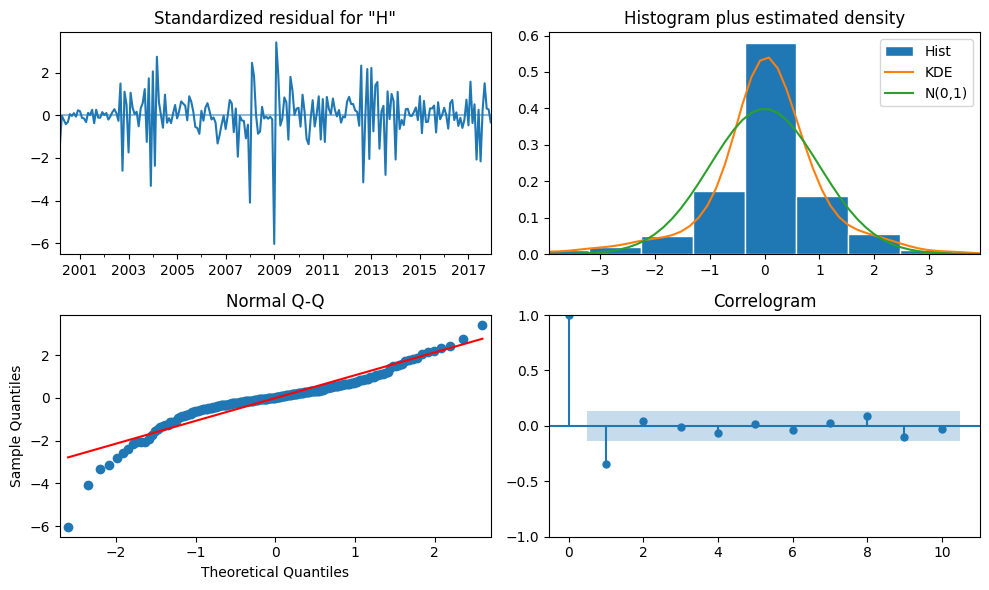

In [ ]:
# Obtain diagnostic plots
fig = arima_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The ARIMA model diagnostics indicate that the residuals are not well‑behaved.

The Normal Q–Q plot shows noticeable deviations from normality, suggesting the residuals are not normally distributed.

Additionally, the correlogram reveals significant autocorrelation outliers, meaning the model has not fully captured the time‑dependent structure.

These results imply that the current ARIMA specification may not be adequate, and alternative orders or seasonal adjustments should be considered.

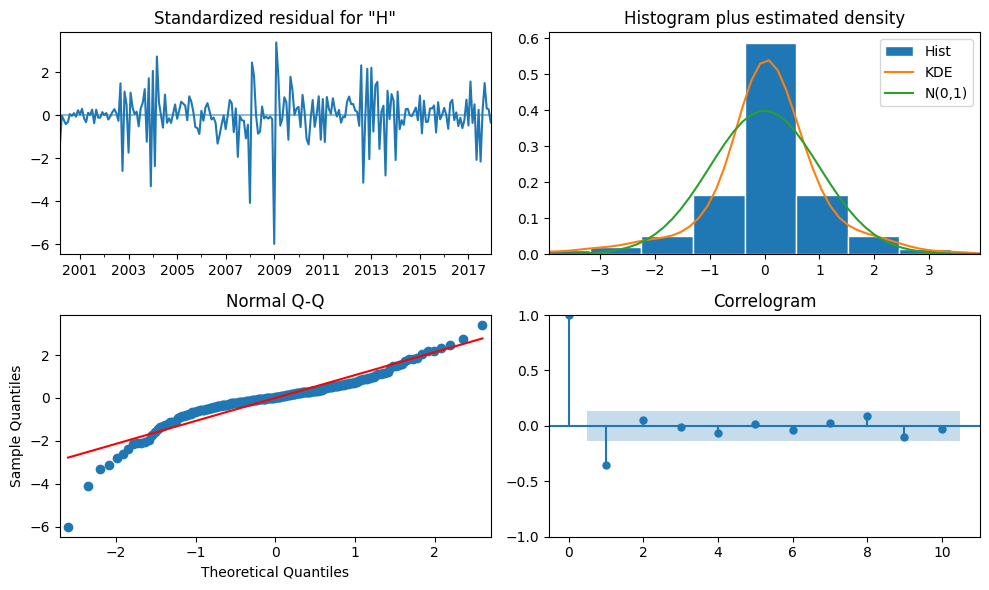

In [ ]:
# Obtain diagnostic plots
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

Same for sarima model

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 385.086
- MSE = 207,923.673
- RMSE = 455.986
- R^2 = 0.991
- MAPE = 0.12%


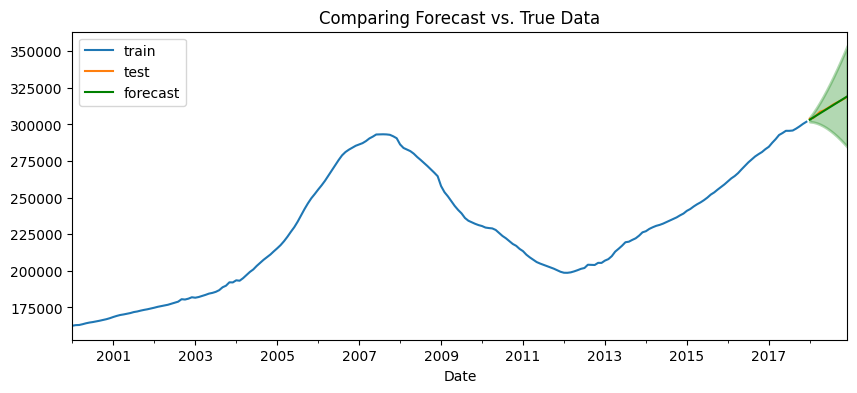

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = arima_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

- MAE (Mean Absolute Error) = 385.086  
On average, the model’s predictions are off by about 385 units from the actual values. It’s a straightforward measure of error magnitude.

- MSE (Mean Squared Error) = 207,923.673  
This is the average of squared errors. Because errors are squared, large mistakes weigh more heavily. It shows overall error magnitude but is less interpretable in raw units.


- RMSE (Root Mean Squared Error) = 455.986  
This is the square root of MSE, bringing the error back to the same scale as the data. It means the typical prediction error is about 456 units. RMSE is often preferred because it’s in the same units as the target variable.

- R² (Coefficient of Determination) = 0.991  
This means the model explains 99.1% of the variance in the data. In other words, the model fits the data extremely well, leaving only 0.9% unexplained.

- MAPE (Mean Absolute Percentage Error) = 0.12%  
On average, the model’s predictions are off by just 0.12% relative to the actual values. This is an excellent result, showing very high accuracy.

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 379.805
- MSE = 205,455.570
- RMSE = 453.272
- R^2 = 0.991
- MAPE = 0.12%


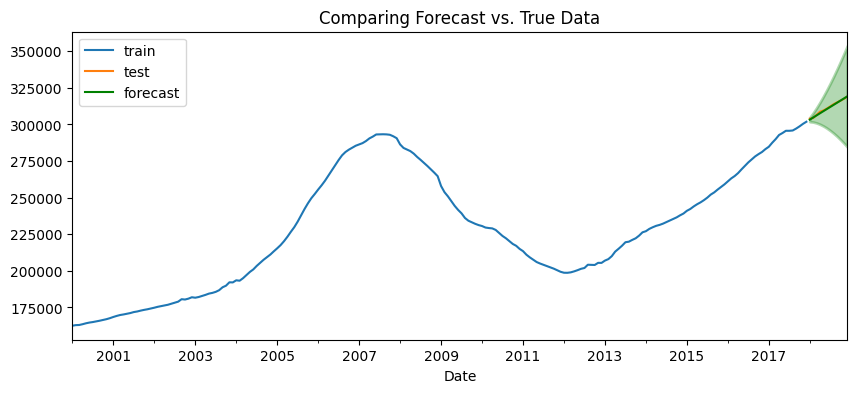

In [ ]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

 SARIMA Regression Metrics
- MAE (Mean Absolute Error) = 379.805  
On average, the forecast is off by about 380 units compared to the actual values. This shows the typical size of prediction errors.

- MSE (Mean Squared Error) = 205,455.570 This is the average of squared errors. Because squaring emphasizes larger mistakes, it highlights overall error magnitude but is less intuitive in raw units.

- RMSE (Root Mean Squared Error) = 453.272  
Taking the square root of MSE brings the error back to the same scale as the data. It means the typical prediction error is about 453 units, which is close to the MAE, confirming consistency.

- R² (Coefficient of Determination) = 0.991  
The model explains 99.1% of the variance in the series. This indicates an excellent fit, with only 0.9% of variation left unexplained.

- MAPE (Mean Absolute Percentage Error) = 0.12%  
On average, the forecast error is just 0.12% of the actual values. This is extremely accurate — essentially less than one percent deviation.

Auto_Arima

In [ ]:
# Default auto_arima will select model based on AIC score
# Tune with pmdarima's auto_arima
# Use auto_arima to find the best ARIMA model parameters
auto_model = pm.auto_arima(train,
                                 start_p=0, start_q=0,
                                 test='adf',       # use adftest to find optimal 'd'
                                 max_p=5, max_q=5, # maximum p and q
                                 m=12,             # frequency of series
                                 d=None,           # let model determine 'd'
                                 seasonal=True,    # No Seasonality
                                 start_P=0,
                                 D=None,             # let model determine 'D'
                                 trace=True,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=3455.126, Time=0.18 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=3453.299, Time=0.03 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=3458.298, Time=0.11 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=3458.183, Time=0.13 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=3455.380, Time=0.09 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=3458.425, Time=0.42 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=3454.641, Time=0.09 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=3456.399, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=3457.674, Time=0.11 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=3455.285, Time=0.04 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 1.278 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(0, 2, 0)   Log Likelih

In [ ]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(0, 2, 0)
(0, 0, 0, 12)


In [ ]:
# Obtain summary of the best model from auto_arima
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(0, 2, 0)   Log Likelihood               -1725.649
Date:                Tue, 21 Apr 2026   AIC                           3453.299
Time:                        23:21:01   BIC                           3456.665
Sample:                    01-31-2000   HQIC                          3454.659
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      5.871e+05   2.82e+04     20.794      0.000    5.32e+05    6.42e+05
===================================================================================
Ljung-Box (L1) (Q):                  28.80   Jarque-Bera (JB):               367.75
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.33   Skew:                            -1.14
Prob(H) (two-sided):                  0.23   Kurtosis:                         9.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

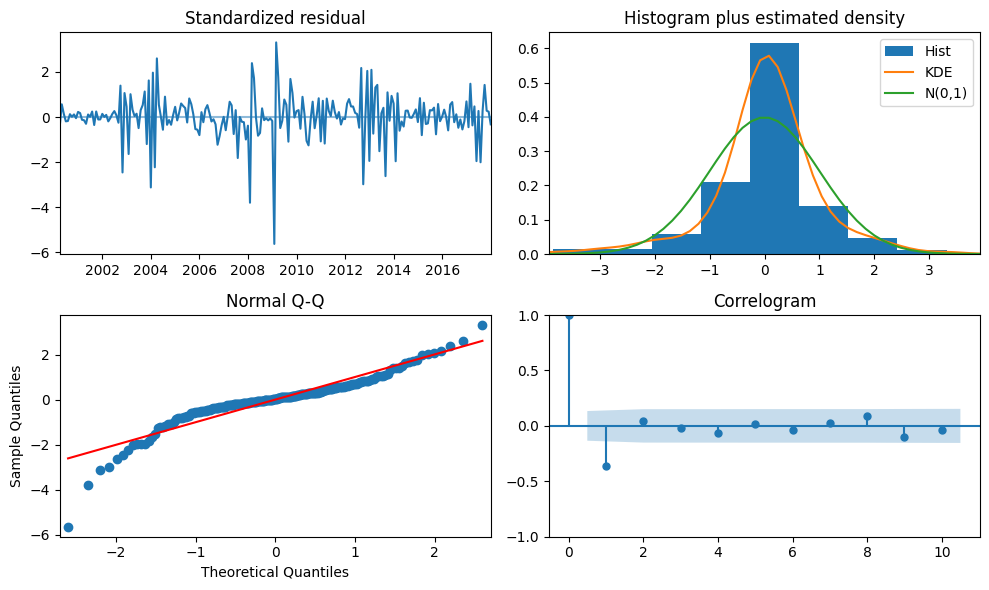

In [ ]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The auto model model diagnostics indicate that the residuals are not well‑behaved.

The Normal Q–Q plot shows noticeable deviations from normality, suggesting the residuals are not normally distributed.

Additionally, the correlogram reveals significant autocorrelation outliers, meaning the model has not fully captured the time‑dependent structure.

These results imply that the current ARIMA specification may not be adequate, and alternative orders or seasonal adjustments should be considered.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 384.272
- MSE = 204,449.052
- RMSE = 452.160
- R^2 = 0.991
- MAPE = 0.12%


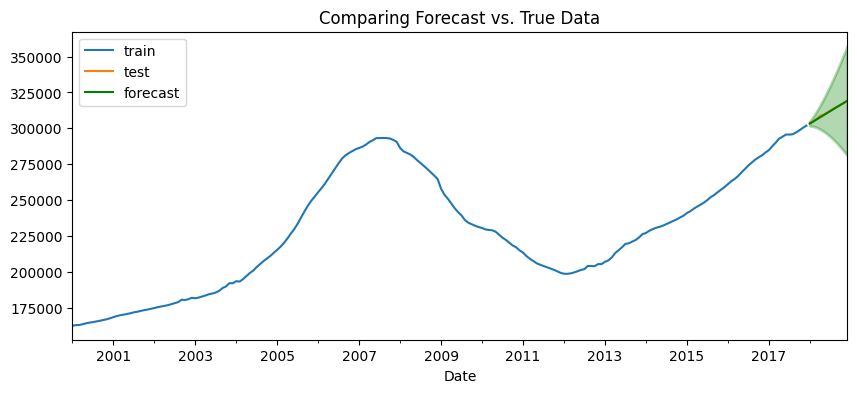

In [ ]:
# Use auto_arima parameters to fit an ARIMA
final_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()

# Obtain summary
final_model.summary()

# Obtain forecast as a dataframe with confidence intervals
forecast_df = final_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

- MAE (Mean Absolute Error) = 384.272  
On average, the forecast is off by about 384 units compared to actual values. This is the typical error magnitude.

- MSE (Mean Squared Error) = 204,449.052  
The average of squared errors. Larger mistakes weigh more heavily here, but it confirms overall error magnitude is low.

- RMSE (Root Mean Squared Error) = 452.160  
The square root of MSE, expressed in the same units as the data. It means the typical prediction error is about 452 units, consistent with the MAE.

- R² (Coefficient of Determination) = 0.991  
The model explains 99.1% of the variance in the series. This indicates an excellent fit, leaving only 0.9% unexplained.

- MAPE (Mean Absolute Percentage Error) = 0.12%  
On average, the forecast error is just 0.12% of actual values. This is exceptionally accurate — essentially less than one percent deviation.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


Predicted home value in State of Oregon 12 months into the future: 337,253.12
Net change in home values over the 12-month forecast: 16,709.42
Percent change in home values over the 12-month forecast: 5.21%


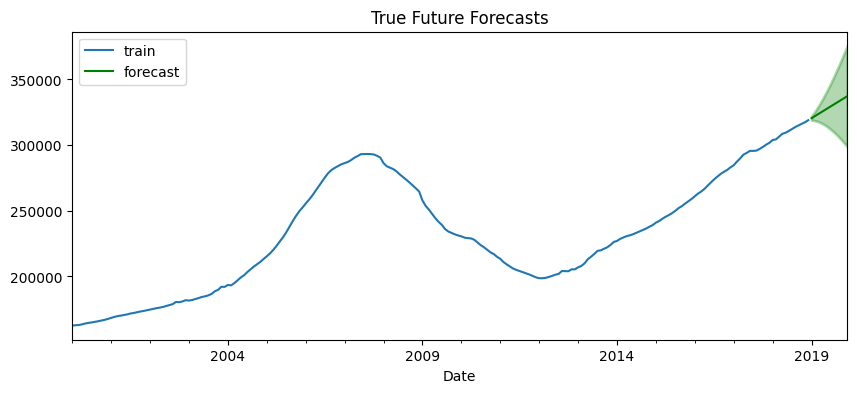

In [ ]:
future_steps = 12

# Find the best ARIMA parameters using auto_arima on the entire dataset
final_auto_model = pm.auto_arima(ts,
                                 start_p=0, start_q=0,
                                 test='adf',       # use adftest to find optimal 'd'
                                 max_p=3, max_q=3, # maximum p and q
                                 m=12,             # frequency of series
                                 d=None,           # let model determine 'd'
                                 seasonal=True,    # Allow seasonality
                                 start_P=0,
                                 D=None,             # let model determine 'D'
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

# Fit the final model on the entire dataset using the parameters found by auto_arima
final_model_full_data = tsa.ARIMA(
    ts, order=final_auto_model.order, seasonal_order=final_auto_model.seasonal_order
).fit()

# Obtain true future forecast (beyond the dataset)
future_forecast_df = final_model_full_data.get_forecast(steps=future_steps).summary_frame()

# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(ts, None, future_forecast_df, title='True Future Forecasts')
# Obtain metrics
# For true future forecasts, there is no 'true' data beyond `ts` to compare against for regression metrics.
# The line below was attempting to compare `ts` (the entire dataset) with `future_forecast_df['mean']`,
# which are separate time series. Removing this line as it's not applicable here.
# regression_metrics_ts(ts, future_forecast_df['mean'])


# Calculate predicted net change in home value
first_forecast_value = future_forecast_df['mean'].iloc[0]
last_forecast_value = future_forecast_df['mean'].iloc[-1]
net_change = last_forecast_value - first_forecast_value

# Calculate percent change
percent_change = (net_change / first_forecast_value) * 100

# Print values for verification
print(f"Predicted home value in State of Oregon 12 months into the future: {last_forecast_value:,.2f}")
print(f"Net change in home values over the 12-month forecast: {net_change:,.2f}")
print(f"Percent change in home values over the 12-month forecast: {percent_change:,.2f}%")

- Predicted home value in State of Oregon 12 months into the future: 337,253.12
- Net change in home values over the 12-month forecast: 16,709.42
- Percent change in home values over the 12-month forecast: 5.21%

In [ ]:
me=df_melted[df_melted['State'].isin(['OR'])].copy()
me.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,99142,262,97229,zip,OR,OR,Portland,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,260209.0
2000-01-31,99178,489,97301,zip,OR,OR,Salem,"Salem, OR",Marion County,109851.0
2000-01-31,99048,528,97045,zip,OR,OR,Oregon City,"Portland-Vancouver-Hillsboro, OR-WA",Clackamas County,204570.0
2000-01-31,99093,549,97124,zip,OR,OR,Hillsboro,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,181574.0
2000-01-31,99252,656,97402,zip,OR,OR,Eugene,"Eugene-Springfield, OR",Lane County,136799.0


In [ ]:
me= me.loc['2018':'2019']
me.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2018-01-31,99142,262,97229,zip,OR,OR,Portland,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,559943.0
2018-01-31,99178,489,97301,zip,OR,OR,Salem,"Salem, OR",Marion County,214290.0
2018-01-31,99048,528,97045,zip,OR,OR,Oregon City,"Portland-Vancouver-Hillsboro, OR-WA",Clackamas County,413672.0
2018-01-31,99093,549,97124,zip,OR,OR,Hillsboro,"Portland-Vancouver-Hillsboro, OR-WA",Washington County,377512.0
2018-01-31,99252,656,97402,zip,OR,OR,Eugene,"Eugene-Springfield, OR",Lane County,245772.0


In [ ]:
# 5. Resample the dataframe as monthly frequency, grouped by City (RegionName)
me_resampled = me.groupby('Date')['Home Value'].mean()
me_resampled.info()
me_resampled.head()

<class 'pandas.core.series.Series'>
DatetimeIndex: 24 entries, 2018-01-31 to 2019-12-31
Series name: Home Value
Non-Null Count  Dtype  
--------------  -----  
24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes


,Home Value
Date,
2018-01-31,303915.116766
2018-02-28,304362.766962
2018-03-31,306535.796460
2018-04-30,308659.562130
2018-05-31,309487.658824


In [ ]:
me_resampled.tail()

,Home Value
Date,
2019-08-31,324371.680352
2019-09-30,324924.070381
2019-10-31,325668.643275
2019-11-30,325732.982301
2019-12-31,327948.384840


# Tableau Workbook

https://public.tableau.com/app/profile/qusta.bahu/viz/BeltExampart3/Story1?publish=yes